In [22]:
from scipy.integrate import quad, simpson
from scipy.optimize import fsolve, minimize
from qutip import *
import inspect

# High-order correction to the evolution operator

Рассмотрим упрощённый гамильтониан МС-гейта с учётом высших порядков по Лэмбу-Дике:
$$
\hat{H} = f(t)\left[a\left(1 - \frac{\eta^2}{2}\right) - \frac{\eta^2}{2}a^\dagger a a \right]S_x + \mathrm{h.c.}
$$

Как мы уже выяснили, учёт высших порядков разложения по Лэмбу-Дике проявляется в появлении члена $S_x^4$ в операторе эволюции: 
\begin{equation}
 U \approx e^{-i\theta_2 S_x^2 - i\theta_4 S_x^4},
\end{equation}
где 
\begin{equation}
\theta_4 = 8i\eta^2 \int |\alpha^2|(\alpha d\alpha^* - \alpha^* d\alpha).
\end{equation}
Видно, что $\theta_4$ определяется как "деформированная площадь" фазовой траектории: это интеграл площади, где у каждого бесконечно малого элемента появляется вес $|\alpha|^2$. 

Для постоянного во времени импульса (для "круглой" фазовой траектории) с числом оборотов $n_{loops}$ 
$$
\theta_4 = \frac{3\pi}{8n_{loops}}.
$$

In [3]:
def theta_4_rect(fmax):
    def integrand(t):
        x = 1 - np.cos(t)
        y = np.sin(t)
        vx = np.sin(t)
        vy = np.cos(t)
        return (x**2 + y**2)*(y*vx - x*vy)
    return fmax**4*quad(integrand, 0, 2*np.pi)[0]

print(f'theta_4 = {theta_4_rect(0.5)/np.pi}pi')

theta_4 = 0.375pi


Продемонстрируем моделированием, что оператор эволюции действительно имеет обозначенную форму. Решим уравнение Шрёдингера для различных значений проекции $S_x$, то есть для различных начальных состояний $|m_x, 0\rangle$, и найдём фазу матричного элемента $\langle m_x, 0|\psi_{fin}\rangle$. Для идеального МС-гейта
$$
\langle m_x, 0|\psi_{fin}\rangle = e^{-\frac{i\pi m_x^2}{2}}.
$$
Мы будем вычислять поправку к этой фазе и сравнивать с аналитической формулой
$$
\delta\theta(m_x) = \delta\theta_2 m_x^2 + \theta_4 m_x^4.
$$

In [21]:
from tdse_solutions import ion_ham, phase_residuals_rect

In [24]:
print(inspect.getsource(ion_ham))

def ion_ham(f_arr, t_arr, eta, m_x, N_cutoff):
    a = destroy(N_cutoff)
    A = a - eta**2/2*a.dag()*a*a
    return QobjEvo([[A,        m_x*np.conj(f_arr)],
                    [A.dag(),  m_x*f_arr]], tlist=t_arr)



In [25]:
print(inspect.getsource(phase_residuals_rect))

def phase_residuals_rect(mx_arr, t_arr, f_max, n_loops, eta, N_cutoff):
    phase_arr = []
    f_arr = f_max*np.exp(-1j*n_loops*t_arr)

    #N_cutoff = get_coherent_cutoff(alpha_est, 1e-7)
    psi0 = fock(N_cutoff, 0)
    for mx in mx_arr:
        ham = ion_ham(f_arr, t_arr, eta, mx, N_cutoff)
        result = sesolve(ham, psi0, t_arr, options={'store_states'     : False,
                                                    'store_final_state': True})
        phase = result.final_state[0,0]*np.exp(1j*np.pi/2*mx**2)
        phase_arr.append(phase)

    phase_arr = np.array(phase_arr)
    return phase_arr



In [6]:
t_gate = 2*np.pi
t_arr = np.linspace(0, t_gate, 4001)

N_cutoff = 600
eta = 0.03

n_ions = 20
mx_arr = np.arange(-n_ions/2, n_ions/2+1)

phase_arr_rect_1 = phase_residuals_rect(mx_arr, t_arr, 1, eta, N_cutoff)

In [7]:
phases_theory_rect_1 = np.exp(0*1j*np.pi/2*eta**2*mx_arr**2 + 3j*np.pi/8*eta**2*mx_arr**4)

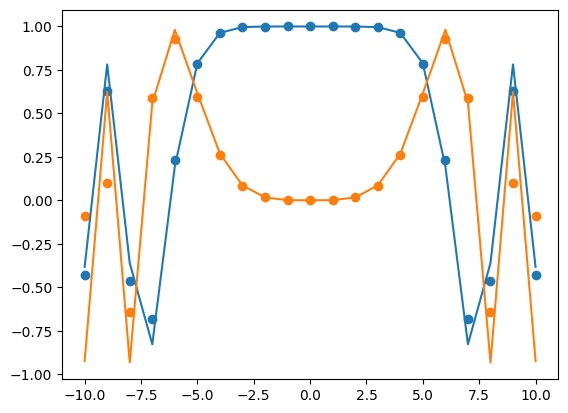

In [8]:
plt.scatter(mx_arr, phase_arr_rect_1.real)
plt.scatter(mx_arr, phase_arr_rect_1.imag)
plt.plot(mx_arr, phases_theory_rect_1.real)
plt.plot(mx_arr, phases_theory_rect_1.imag)

Из рисунка видно, что `phase_residuals` действительно описываются аналитической формулой.

# Definition of the lemniscate pulse

Если удастся подобрать такой импульс, что $\theta_4$ занулится, это позволит добиться ещё больших фиделити GHZ-состояния. Интерпретация $\theta_4$ позволяет придумать фазовую траекторию, удовлетворяющую одновременно условию $\theta_4 = 0$ и $\theta_2 = \pi/4$ (где 
$\theta_2$ - обычная фаза спин-спинового взаимодействия,
$$
\theta_2 = i\int (\alpha d\alpha^* - \alpha^* d\alpha).
$$
Фазовая траектория должна иметь форму "восьмёрки". Внутреннее и внешнее кольца "восьмёрки" дают вклады в взвешенную площадь разного знака из-за разных направлений обхода. Параметры восьмёрки (соотношение размеров колец) нужно подобрать так, чтобы $\theta_4=0$.

Мы возьмём восьмёрку, параметризованную формулами
$$
x = f_{max}(1 - \cos(t))
$$
$$
y = f_{max}\sin(t)(1 - a + a\cos(t)).
$$
Восьмёрка получается при $a > 1/2$. 

This self-intersecting curve at $a=1$ reduces to the Lemniscate of Gerono. 

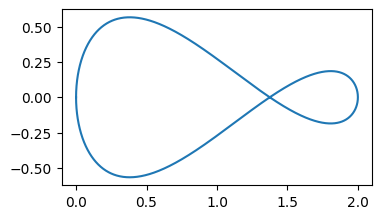

In [9]:
t = np.linspace(0, 2*np.pi, 2001)
a = 0.7274788716591838
x = 1 - np.cos(t)
y = np.sin(t)*(1 - a + a*np.cos(t))
alpha = x + 1j*y
plt.figure(figsize=(4,3))
plt.gca().set_aspect('equal')
plt.plot(x, y)

Решение уравнения $\theta_4=0$ действительно существует, это  $a = a_{opt} = 0.7274789$. Код ниже находит это значение. Рисунок выше построен для этого значения и для $r=1$.

In [10]:
def theta_2(a, fmax):
    def integrand(t):
        x = 1 - np.cos(t)
        y = np.sin(t)*(1 - a + a*np.cos(t))
        vx = np.sin(t)
        return 2*y*vx
    return fmax**2*quad(integrand, 0, 2*np.pi)[0]


def theta_4(a, fmax):
    def integrand(t):
        x = 1 - np.cos(t)
        y = np.sin(t)*(1 - a + a*np.cos(t))
        vx = np.sin(t)
        vy = np.cos(t)*(1-a) + a*np.cos(2*t)
        return (x**2 + y**2)*(y*vx - x*vy)
    return fmax**4*quad(integrand, 0, 2*np.pi)[0]


def theta_2_analytical(a, fmax):
    return 2*np.pi*(1 - a)*fmax**2


def theta_4_analytical(a, fmax):
    return math.pi*(6 - 10*a + 7/2*a**2 - 3/2*a**3)*fmax**4

In [11]:
a_opt = fsolve(theta_4, 0.73, args=(1))[0]
print(f'a_opt = {a_opt}')
theta_ratio = theta_2(a_opt, 1)/theta_2(0, 1)
print(f'theta_2 = {theta_ratio}')

a_opt = 0.7274788716591838
theta_2 = 0.2725211283408162


Величины $\theta_2$ и $\theta_4$ для таких фазовых траекторий также могут быть найдены аналитически:

\begin{equation}
    \theta_2 = -2\pi(1 - a)
\end{equation}
\begin{equation}
    \theta_4 = \pi\left(6 - 10a + \frac{7}{2}a^2 - \frac{3}{2}a^3\right).
\end{equation}

Уравнение $\theta_4 = 0$, таким образом, сводится к алгебраическому третьей степени.

In [12]:
np.roots([-3/2, 7/2, -10, 6])

array([0.80292723+2.20312263j, 0.80292723-2.20312263j,
       0.72747887+0.j        ])

Импульс, соответствующий этой фазовой траектории, может быть найден из уравнения 
$$
f = i\frac{d\alpha}{dt}.
$$
$$
f(t) = -f_{max}[e^{-it} - a(\cos{t} - \cos{2t})], \quad t \in [0, 2\pi].
$$
где $f_{max}$ находится из условия $\theta_2 = \pi/4$. При $a=0$ $f_{max} = 1/2$. При нашем значении $a = a_{opt}$ значение $f_{max}$ равно $0.95778915$. Импульс соответствует специально модулированному полихроматическому импульсу, где пара компонент отстроены от сайдбендов, как обычно, а ещё пара компонент светит точно в сайдбенды.

In [26]:
from tdse_solutions import lemniscate_f

In [29]:
print(inspect.getsource(lemniscate_f))

def lemniscate_f(t, a):
    return np.exp(-1j*t) - a*(np.cos(t) - np.cos(2*t))



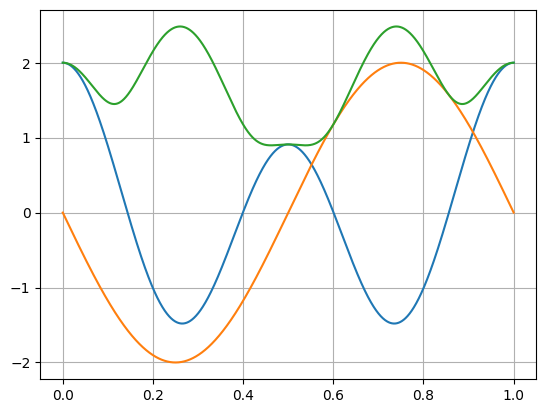

In [14]:
t_gate = 2*np.pi
t_arr = np.linspace(0, t_gate, 4001)
plt.plot(t_arr/2/np.pi, 2*lemniscate_f(t_arr, a_opt).real)
plt.plot(t_arr/2/np.pi, 2*lemniscate_f(t_arr, a_opt).imag)
plt.plot(t_arr/2/np.pi, 2*np.abs(lemniscate_f(t_arr, a_opt)))
plt.grid()

Для проверки "дееспособности" этих импульсов нужно провести численное моделирование. Повторим расчёт поправки к фазе, проделанный выше для прямоугольного импульса.

Мы симулируем исходный гамильтониан для различных проекций $\hat{S}_x$ и находим фазу, набегающую на начальном состоянии. Для идеального МС-гейта она должна быть равна 
$$
\phi = \frac{\pi S_x^2}{2}.
$$
Мы будем вычислять поправку $\Delta\phi$ к этой фазе.

На графиках ниже представлены зависимости $\Delta\phi$ от проекции  $m_x$ для прямоугольного и модифицированного импульса. 

In [ ]:
from tdse_solutions import phase_residuals_lemniscate

In [30]:
print(inspect.getsource(phase_residuals_lemniscate))

def phase_residuals_lemniscate(mx_arr, t_arr, a, f_max, eta, N_cutoff):
    phase_arr = []
    f_arr = f_max*lemniscate_f(t_arr, a)
    psi0 = fock(N_cutoff, 0)
    for mx in mx_arr:
        ham = ion_ham(f_arr, t_arr, eta, mx, N_cutoff)
        result = sesolve(ham, psi0, t_arr, options={'store_states' : False, 
                                                'store_final_state': True})
        phase = result.final_state[0,0]*np.exp(1j*np.pi/2*mx**2)
        phase_arr.append(phase)

    phase_arr = np.array(phase_arr)
    return phase_arr



In [16]:
t_gate = 2*np.pi
t_arr = np.linspace(0, t_gate, 4001)

n_ions = 20
mx_arr = np.arange(-n_ions/2, n_ions/2+1)

a1 = 0.6
a2 = a_opt
a3 = 0.8

f1 = 1/2*math.sqrt(2*np.pi/theta_2_analytical(a1, 1))
f2 = 1/2*math.sqrt(2*np.pi/theta_2_analytical(a2, 1))
f3 = 1/2*math.sqrt(2*np.pi/theta_2_analytical(a3, 1))

phase_arr_lemniscate_test_1 = phase_residuals_lemniscate(mx_arr, t_arr, a1, f1, eta, N_cutoff)
phase_arr_lemniscate_test_2 = phase_residuals_lemniscate(mx_arr, t_arr, a2, f2, eta, N_cutoff)
phase_arr_lemniscate_test_3 = phase_residuals_lemniscate(mx_arr, t_arr, a3, f3, eta, N_cutoff)

In [20]:
f2

0.9577891547561114

In [17]:
theta_2_test_1 = theta_2_analytical(a1, f1)
theta_4_test_1 = theta_4_analytical(a1, f1)

theta_2_test_2 = theta_2_analytical(a2, f2)
theta_4_test_2 = theta_4_analytical(a2, f2)

theta_2_test_3 = theta_2_analytical(a3, f3)
theta_4_test_3 = theta_4_analytical(a3, f3)

For $a = a_1$:

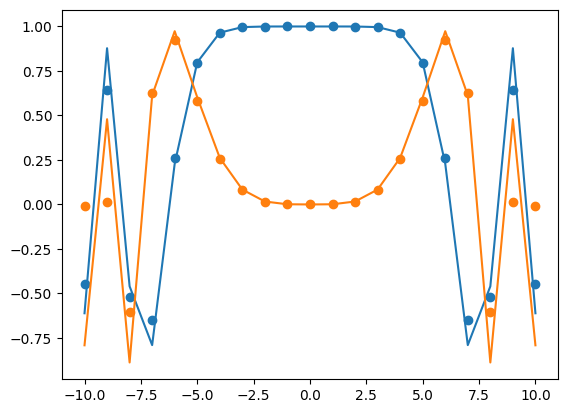

In [18]:
plt.scatter(mx_arr, phase_arr_lemniscate_test_1.real)
plt.scatter(mx_arr, phase_arr_lemniscate_test_1.imag)

phases_theory_lem_test_1 = np.exp(0*1j*np.pi/2*eta**2*mx_arr**2 + 1j*theta_4_test_1*eta**2*mx_arr**4)

plt.plot(mx_arr, phases_theory_lem_test_1.real)
plt.plot(mx_arr, phases_theory_lem_test_1.imag)

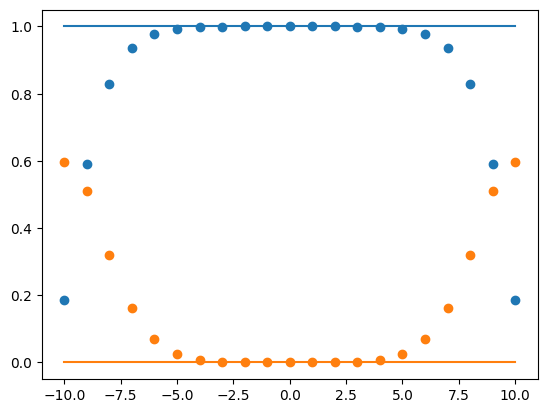

In [19]:
plt.scatter(mx_arr, phase_arr_lemniscate_test_2.real)
plt.scatter(mx_arr, phase_arr_lemniscate_test_2.imag)

phases_theory_lem_test_2 = np.exp(0*1j*np.pi/2*eta**2*mx_arr**2 + 1j*theta_4_test_2*eta**2*mx_arr**4)

plt.plot(mx_arr, phases_theory_lem_test_2.real)
plt.plot(mx_arr, phases_theory_lem_test_2.imag)

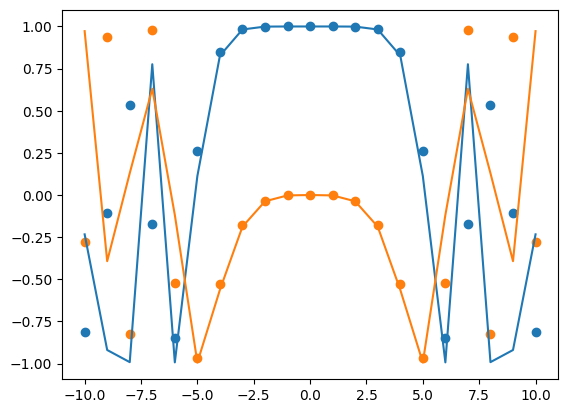

In [131]:
plt.scatter(mx_arr, phase_arr_lemniscate_test_3.real)
plt.scatter(mx_arr, phase_arr_lemniscate_test_3.imag)

phases_theory_lem_test_3 = np.exp(0*1j*np.pi/2*eta**2*mx_arr**2 + 1j*theta_4_test_3*eta**2*mx_arr**4)

plt.plot(mx_arr, phases_theory_lem_test_3.real)
plt.plot(mx_arr, phases_theory_lem_test_3.imag)

# Fidelity calculation

For GHZ preparation, the initial state is $\left|\left.\frac{n}{2}, \frac{n}{2}\right.\right\rangle_z$. It is decomposed into the states in $x$-basis as follows:
$$
\left|\left.\frac{n}{2}, \frac{n}{2}\right.\right\rangle_z = \sum_{k=0}^{n} \sqrt{\frac{C^{k}_n}{2^n}}\left|\left.\frac{n}{2}, \frac{k-n}{2}\right.\right\rangle_x
$$
The result if the ideal gate action reads
$$
|\psi_{ideal}\rangle = e^{-\frac{i\pi}{2}S_x^2}\left|\left.\frac{n}{2}, \frac{n}{2}\right.\right\rangle_z = 
\sum_{k=0}^{n} \sqrt{\frac{C^{k}_n}{2^n}}
e^{-\frac{i\pi}{2}\left(\frac{k-n}{2}\right)^2}
\left|\left.\frac{n}{2}, \frac{k-n}{2}\right.\right\rangle_x \otimes |0\rangle.
$$
The real final state can be written as
$$
|\psi_{fin}\rangle = \sum_k \sqrt{\frac{C^{k}_n}{2^n}} \left|\left.\frac{n}{2}, \frac{k-n}{2}\right.\right\rangle_x \otimes |\psi_k\rangle.
$$
The overlap:
$$
\langle\psi_{ideal}|\psi_{fin}\rangle = 
\sum \frac{C^{k}_n}{2^n}\langle 0 |\psi_k\rangle.
$$
$$
F = |\langle\psi_{ideal}|\psi_{fin}\rangle|^2.
$$

In [31]:
from tdse_solutions import fidelity_from_phase_residuals, phonon_excitation_prob

print(inspect.getsource(fidelity_from_phase_residuals))
print(inspect.getsource(phonon_excitation_prob))

def fidelity_from_phase_residuals(phase_arr):
    n_ions = phase_arr.size - 1
    overlap = np.sum([math.comb(n_ions, k)/2**n_ions*phase_arr[k] for k in range(n_ions+1)])
    return np.abs(overlap)**2

def phonon_excitation_prob(phase_arr):
    n_ions = phase_arr.size - 1
    return np.sum([math.comb(n_ions, k)/2**n_ions*(1 - abs(phase_arr[k])**2) 
                  for k in range(n_ions+1)])



In [133]:
print(phonon_excitation_prob(phase_arr_rect_1))
print(phonon_excitation_prob(phase_arr_lemniscate_test_1))
print(phonon_excitation_prob(phase_arr_lemniscate_test_2))
print(phonon_excitation_prob(phase_arr_lemniscate_test_3))

0.003030580108918186
0.0029696438292843887
0.0014262096356214811
9.434341480486328e-05


In [134]:
def inf_with_param_shifts(delta_thetas, phase_arr):
    delta_theta_2, delta_theta_4 = delta_thetas
    n_ions = phase_arr.size - 1
    mx_arr = np.arange(-n_ions/2, n_ions/2+1)
    return 1 - fidelity_from_phase_residuals(phase_arr*
                    np.exp(-1j*mx_arr**2*delta_theta_2 - 1j*mx_arr**4*delta_theta_4))

def inf_with_param_shifts_6(delta_thetas, phase_arr):
    delta_theta_2, delta_theta_4, delta_theta_6 = delta_thetas
    n_ions = phase_arr.size - 1
    mx_arr = np.arange(-n_ions/2, n_ions/2+1)
    return 1 - fidelity_from_phase_residuals(phase_arr_lem*
                    np.exp(-1j*mx_arr**2*delta_theta_2 
                          - 1j*mx_arr**4*delta_theta_4
                          - 1j*mx_arr**6*delta_theta_6))

In [136]:
t_gate = 2*np.pi
t_arr = np.linspace(0, t_gate, 4001)
f_max = 1/2/math.sqrt(theta_ratio)

n_ions = 20
mx_arr = np.arange(-n_ions/2, n_ions/2+1)

In [137]:
phase_arr_1  = phase_residuals_rect(mx_arr, t_arr, 1, eta, N_cutoff)
phase_arr_2  = phase_residuals_rect(mx_arr, t_arr, 2, eta, N_cutoff)
phase_arr_3  = phase_residuals_rect(mx_arr, t_arr, 3, eta, N_cutoff)
phase_arr_4  = phase_residuals_rect(mx_arr, t_arr, 4, eta, N_cutoff)
phase_arr_8  = phase_residuals_rect(mx_arr, t_arr, 8, eta, N_cutoff)
phase_arr_lem = phase_residuals_lemniscate(mx_arr, t_arr, a2, f2, eta, N_cutoff)

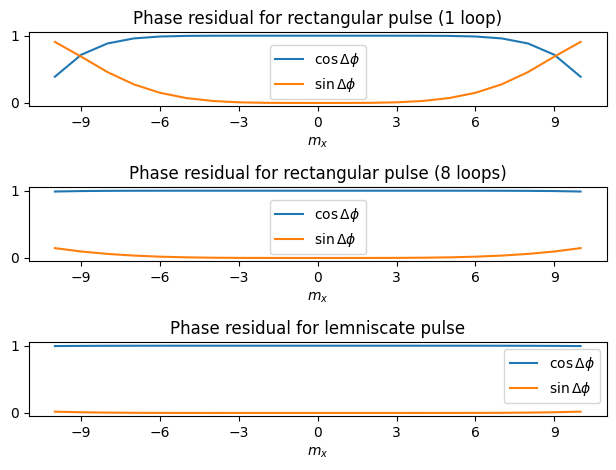

In [119]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)

ax1.set_title('Phase residual for rectangular pulse (1 loop)')
ax1.plot(mx_arr, np.real(phase_arr_1), label='$\cos{\Delta\phi}$')
ax1.plot(mx_arr, np.imag(phase_arr_1), label='$\sin{\Delta\phi}$')
ax1.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax1.set_xlabel('$m_x$')
ax1.legend()

ax2.set_title('Phase residual for rectangular pulse (8 loops)')
ax2.plot(mx_arr, np.real(phase_arr_8), label='$\cos{\Delta\phi}$')
ax2.plot(mx_arr, np.imag(phase_arr_8), label='$\sin{\Delta\phi}$')
ax2.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax2.set_xlabel('$m_x$')
ax2.legend()

ax3.set_title('Phase residual for lemniscate pulse')
ax3.plot(mx_arr, np.real(phase_arr_lem), label='$\cos{\Delta\phi}$')
ax3.plot(mx_arr, np.imag(phase_arr_lem), label='$\sin{\Delta\phi}$')
ax3.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax3.set_xlabel('$m_x$')
ax3.legend()

plt.tight_layout()
plt.show()

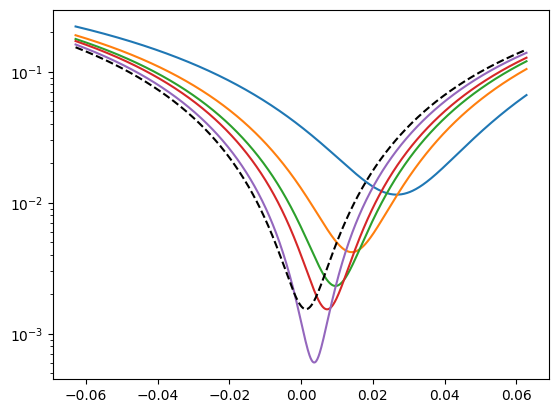

In [138]:
delta_theta_2_arr = np.linspace(-0.02, 0.02, 801)*np.pi

inf_arr_1 = []
inf_arr_1s = []
inf_arr_2 = []
inf_arr_3 = []
inf_arr_4 = []
inf_arr_8 = []
inf_arr_lem = []

for delta_theta_2 in delta_theta_2_arr:
    inf_arr_1.append(1 - fidelity_from_phase_residuals(phase_arr_1*
                                np.exp(-1j*mx_arr**2*delta_theta_2)))
    # inf_arr_1s.append(1 - fidelity_from_phase_residuals(phase_arr_1sym*
    #                             np.exp(-1j*mx_arr**2*delta_theta_2)))
    inf_arr_2.append(1 - fidelity_from_phase_residuals(phase_arr_2*
                        np.exp(-1j*(mx_arr**2*delta_theta_2))))
    inf_arr_3.append(1 - fidelity_from_phase_residuals(phase_arr_3*
                        np.exp(-1j*(mx_arr**2*delta_theta_2))))
    inf_arr_4.append(1 - fidelity_from_phase_residuals(phase_arr_4*
                        np.exp(-1j*(mx_arr**2*delta_theta_2))))
    inf_arr_8.append(1 - fidelity_from_phase_residuals(phase_arr_8*
                        np.exp(-1j*(mx_arr**2*delta_theta_2))))
    inf_arr_lem.append(1 - fidelity_from_phase_residuals(phase_arr_lem*
                        np.exp(-1j*(mx_arr**2*delta_theta_2))))

plt.plot(delta_theta_2_arr, inf_arr_1)
plt.plot(delta_theta_2_arr, inf_arr_2)
plt.plot(delta_theta_2_arr, inf_arr_3)
plt.plot(delta_theta_2_arr, inf_arr_4)
plt.plot(delta_theta_2_arr, inf_arr_8)
plt.plot(delta_theta_2_arr, inf_arr_lem, 'k--')
plt.yscale('log')

In [88]:
delta_theta_2_arr = np.linspace(-0.005, 0.005, 201)*np.pi
delta_theta_4_arr = np.linspace(-0.001, 0.001, 200)*np.pi

inf_arr_lem_2d = []

for delta_theta_2 in delta_theta_2_arr:
    inf_arr_lem_2d.append([])
    for delta_theta_4 in delta_theta_4_arr:
        inf_arr_lem_2d[-1].append(1 - fidelity_from_phase_residuals(phase_arr_lem*
                    np.exp(-1j*mx_arr**2*delta_theta_2 - 1j*mx_arr**4*delta_theta_4)))
inf_arr_lem_2d = np.array(inf_arr_lem_2d)

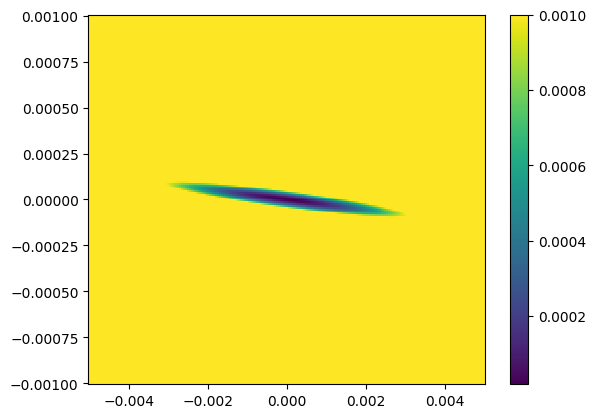

In [89]:
plt.pcolormesh(delta_theta_2_arr/np.pi, delta_theta_4_arr/np.pi, 
               inf_arr_lem_2d.T, vmax=0.001)
plt.colorbar()

In [139]:
result = minimize(inf_with_param_shifts, x0=[0,0], args=(phase_arr_lem))
#dth2_opt, dth4_opt, dth6_opt = result.x
dth2_opt, dth4_opt = result.x
print(result.x/np.pi, result.fun)

[-3.64300448e-04  2.90210279e-05] 0.0014498306227064273


In [91]:
#inf_with_param_shifts([-0.00078069, -0.00065875], phase_arr_lem)

In [140]:
print(min(inf_arr_1), phonon_excitation_prob(phase_arr_1))
print(min(inf_arr_2), phonon_excitation_prob(phase_arr_2))
print(min(inf_arr_3), phonon_excitation_prob(phase_arr_3))
print(min(inf_arr_4), phonon_excitation_prob(phase_arr_4))
print(min(inf_arr_8), phonon_excitation_prob(phase_arr_8))
print(min(inf_arr_lem),  phonon_excitation_prob(phase_arr_lem))

0.01149847183871855 0.003030580108918186
0.004183003747595948 0.0015950963269670345
0.0023085188503709775 0.0010829921140802158
0.0015302816581150847 0.0008199693498379361
0.0006010128967766093 0.00041589675726453576
0.0015350094409593007 0.0014262096356214811


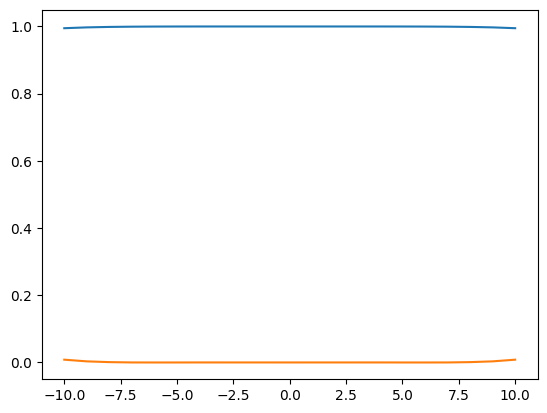

In [93]:
#plt.plot(mx_arr, (phase_arr_lem).real)
#plt.plot(mx_arr, (phase_arr_lem).imag)
#plt.plot(mx_arr, (phase_arr_8*np.exp(-1j*mx_arr**2*0.009)).real)
#plt.plot(mx_arr, (phase_arr_8*np.exp(-1j*mx_arr**2*0.009)).imag)

plt.plot(mx_arr, (phase_arr_lem*np.exp(-1j*mx_arr**2*dth2_opt - 1j*mx_arr**4*dth4_opt)).real)
plt.plot(mx_arr, (phase_arr_lem*np.exp(-1j*mx_arr**2*dth2_opt - 1j*mx_arr**4*dth4_opt)).imag)

# Symmetric pulses

In [141]:
def phase_residuals_rect_sym(mx_arr, t_arr, n_loops, eta, N_cutoff):
    phase_arr = []
    t_gate = t_arr[-1]
    f_arr = math.sqrt(2*n_loops)/2*np.where(t_arr < t_arr[-1]/2, 
                                          np.exp(-2j*n_loops*t_arr),
                                         -np.exp(-2j*n_loops*t_arr))
    psi0 = fock(N_cutoff, 0)
    for mx in mx_arr:
        ham = ion_ham(f_arr, t_arr, eta, mx, N_cutoff)
        result = sesolve(ham, psi0, t_arr, options={'store_states' : False, 
                                                'store_final_state': True})
        phase = result.final_state[0,0]*np.exp(1j*np.pi/2*mx**2)
        phase_arr.append(phase)
    
    phase_arr = np.array(phase_arr)
    return phase_arr

In [142]:
def phase_residuals_lemniscate_sym(mx_arr, t_arr, a, f_max, eta, N_cutoff):
    phase_arr = []
    f_arr = f_max*np.where(t_arr < t_arr[-1]/2,
                           lemniscate_f(2*t_arr, a),
                          -lemniscate_f(2*t_arr, a))
    psi0 = fock(N_cutoff, 0)
    for mx in mx_arr:
        ham = ion_ham(f_arr, t_arr, eta, mx, N_cutoff)
        result = sesolve(ham, psi0, t_arr, options={'store_states' : False, 
                                                'store_final_state': True})
        phase = result.final_state[0,0]*np.exp(1j*np.pi/2*mx**2)
        phase_arr.append(phase)
    
    phase_arr = np.array(phase_arr)
    return phase_arr

In [1]:
phase_arr_1sym = phase_residuals_rect_sym(mx_arr, t_arr, 1, eta, N_cutoff)
phase_arr_2sym = phase_residuals_rect_sym(mx_arr, t_arr, 2, eta, N_cutoff)
phase_arr_3sym = phase_residuals_rect_sym(mx_arr, t_arr, 3, eta, N_cutoff)
phase_arr_6sym = phase_residuals_rect_sym(mx_arr, t_arr, 6, eta, N_cutoff)
phase_arr_8sym = phase_residuals_rect_sym(mx_arr, t_arr, 8, eta, N_cutoff)

NameError: name 'phase_residuals_rect_sym' is not defined

In [144]:
phase_arr_lem_sym = phase_residuals_lemniscate_sym(mx_arr, t_arr, a2, math.sqrt(2)*f2, eta, N_cutoff)

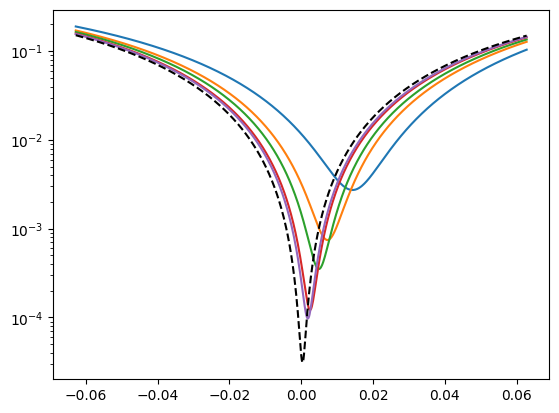

In [146]:
delta_theta_2_arr = np.linspace(-0.02, 0.02, 801)*np.pi

inf_arr_1s = []
inf_arr_2s = []
inf_arr_3s = []
inf_arr_6s = []
inf_arr_8s = []
inf_arr_lem_s = []

for delta_theta_2 in delta_theta_2_arr:
    inf_arr_1s.append(1 - fidelity_from_phase_residuals(phase_arr_1sym*
                                np.exp(-1j*mx_arr**2*delta_theta_2)))
    inf_arr_2s.append(1 - fidelity_from_phase_residuals(phase_arr_2sym*
                                np.exp(-1j*mx_arr**2*delta_theta_2)))
    inf_arr_3s.append(1 - fidelity_from_phase_residuals(phase_arr_3sym*
                                np.exp(-1j*mx_arr**2*delta_theta_2)))
    inf_arr_6s.append(1 - fidelity_from_phase_residuals(phase_arr_6sym*
                                np.exp(-1j*mx_arr**2*delta_theta_2)))
    inf_arr_8s.append(1 - fidelity_from_phase_residuals(phase_arr_8sym*
                                np.exp(-1j*mx_arr**2*delta_theta_2))) 
    inf_arr_lem_s.append(1 - fidelity_from_phase_residuals(phase_arr_lem_sym*
                                np.exp(-1j*mx_arr**2*delta_theta_2)))

plt.plot(delta_theta_2_arr, inf_arr_1s)
plt.plot(delta_theta_2_arr, inf_arr_2s)
plt.plot(delta_theta_2_arr, inf_arr_3s)
plt.plot(delta_theta_2_arr, inf_arr_6s)
plt.plot(delta_theta_2_arr, inf_arr_8s)
plt.plot(delta_theta_2_arr, inf_arr_lem_s, 'k--')

#plt.plot(delta_theta_2_arr, inf_arr_lem, 'k--')
plt.yscale('log')
#plt.ylim(1e-5, 1e-3)
#plt.xlim(-0.005, 0.005)

In [80]:
result = minimize(inf_with_param_shifts, x0=[0,0], args=(phase_arr_lem_sym))
#dth2_opt, dth4_opt, dth6_opt = result.x
dth2_opt, dth4_opt = result.x
print(result.x/np.pi, result.fun)

[-2.20951930e-05  1.63467988e-06] 2.2688710883067564e-05


In [100]:
print(min(inf_arr_1s))
print(min(inf_arr_2s))
print(min(inf_arr_3s))
print(min(inf_arr_6s))
print(min(inf_arr_8s))
print(min(inf_arr_lem_s))

4.372798756957508e-05
2.1823948089361167e-05
2.3130711169327967e-05
3.8309710731154745e-05
5.028190656897191e-05
2.2756051680006273e-05


In [101]:
print(phonon_excitation_prob(phase_arr_1sym))
print(phonon_excitation_prob(phase_arr_2sym))
print(phonon_excitation_prob(phase_arr_3sym))
print(phonon_excitation_prob(phase_arr_6sym))
print(phonon_excitation_prob(phase_arr_8sym))
print(phonon_excitation_prob(phase_arr_lem_sym))

6.24250689042251e-06
1.2344590273683885e-05
1.8652712283754704e-05
3.718267532096157e-05
4.957480955141165e-05
2.275408231966312e-05


# Check for the `fidelity_from_phase_residuals` function 

In [34]:
phase_arr_check = phase_residuals_rect(mx_arr, t_arr, 2, eta, N_cutoff)
inf_from_res = 1 - fidelity_from_phase_residuals(phase_arr_check)
print(inf_from_res)

0.02510723329983955


In [35]:
def ion_ham_full(f_arr, t_arr, eta, n_ions, N_cutoff):
    Sx = jmat(n_ions/2, 'x')
    a = destroy(N_cutoff)
    A = (1 - eta**2/2)*a - eta**2/2*a.dag()*a*a
    return QobjEvo([[tensor(Sx, A),       np.conj(f_arr)],
                    [tensor(Sx, A.dag()), f_arr]], tlist=t_arr)

In [36]:
f_arr = math.sqrt(2)/2*np.exp(-2j*t_arr)
ham_full = ion_ham_full(f_arr, t_arr, eta, n_ions, N_cutoff)
psi0 = tensor(fock(n_ions+1, 0), fock(N_cutoff, 0))
result = sesolve(ham_full, psi0, tlist=t_arr)

In [37]:
Sx = jmat(n_ions/2, 'x')
psi_id = tensor((-1j*np.pi/2*Sx**2).expm()*fock(n_ions+1, 0), fock(N_cutoff, 0))

In [38]:
inf_num = 1 - abs(result.final_state.dag()*psi_id)**2
print(f'{inf_from_res}\n{inf_num}')

0.02510723329983955
0.025096948636232908


# Plots of $\theta_2$ and $\theta_4$ as functions of $a$

Text(0.5, 0, '$a$')

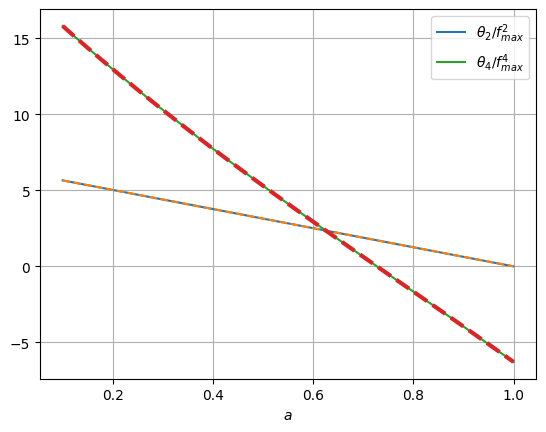

In [154]:
a_range = np.linspace(0.1, 1, 91)

theta_2_range = [theta_2(a, 1) for a in a_range]
theta_4_range = [theta_4(a, 1) for a in a_range]

plt.plot(a_range, theta_2_range, label=r'$\theta_2/f_{max}^2$')
plt.plot(a_range, 2*np.pi*(1 - a_range), linestyle='--')
plt.plot(a_range, theta_4_range, label=r'$\theta_4/f_{max}^4$')

#math.pi*(3/4*(1-a)**3 + 3/8*(1-a)*a**2 + (1-a) + 1/4*(1 - 3*a))

    # math.pi*(((1-a)**3 + 1/2*(1-a)*a**2) + ((1-a) + 1/4*(1 - 3*a))*4)
    # math.pi*((3/4*(1-a)**3 + 3/8*(1-a)*a**2)*4/3 + ((1-a) + 1/4*(1 - 3*a))*4)
     #math.pi*(2 - 4*a + 21/8*a**2 - 9/8*a**3)*fmax**4



plt.plot(a_range, theta_4_analytical(a_range, 1), linestyle='--', linewidth=3)

plt.legend()
plt.grid()
plt.xlabel('$a$')

In [148]:
np.sum(np.abs(theta_4_analytical(a_range, 1) - theta_4_range))

np.float64(6.308148448042061e-14)

In [65]:
epsilon = 1e-6
theta_2_diff = (theta_2(a_opt + epsilon, 1) - theta_2(a_opt - epsilon, 1))/2/epsilon
theta_4_diff = (theta_4(a_opt + epsilon, 1) - theta_4(a_opt - epsilon, 1))/2/epsilon
print(theta_2_diff)
print(theta_4_diff)

-6.283185307376371
-6.159890634363507


При $a = a_{opt}$ 

\begin{equation}
\frac{d\theta_2}{df_{max}} = \frac{\pi}{f_{max}},
\end{equation}
\begin{equation}
\frac{d\theta_2}{da} = -2\pi f_{max}^2,
\end{equation}
\begin{equation}
\frac{d\theta_4}{da} = -6.15989\cdot f_{max}^4.
\end{equation}

In [34]:
#2 - 4*a + 21/8*a**2 - 9/8*a**3


array([0.79116864+1.31957519j, 0.79116864-1.31957519j,
       0.75099606+0.j        ])

In [46]:
theta_4_analytical(0, 1/2)/np.pi

0.125

In [149]:
from sympy import Symbol, expand

In [150]:
q = Symbol('q')

In [152]:
expand((((1-q)**3 + 1/2*(1-q)*q**2) + ((1-q) + 1/4*(1 - 3*q))*4))

-1.5*q**3 + 3.5*q**2 - 10.0*q + 6.0